**SPDX-License-Identifier:** MIT  
**Copyright (C) 2026 Jinghui Zhong**  
*Companion source code for Chapter 2 of the book "Genetic Programming Algorithms and Applications" (《遗传编程算法及其应用》).*

# SGP Notebook 2: PMLB 基准测试与可视化

在 8 个 PMLB (Penn Machine Learning Benchmark) 真实回归数据集上运行 SGP 符号回归，包含完整的基准评估可视化。

涵盖不同样本量 (50~500)、不同特征数 (2~7) 的真实数据集，展示 SGP 在非合成场景下的表现。

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sgp import SGP

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('环境就绪')

环境就绪


## PMLB 数据集

从 [PMLB](https://github.com/EpistasisLab/penn-ml-benchmarks) 选取 8 个回归数据集，涵盖不同样本量和特征数。

In [2]:
from pmlb import fetch_data

# PMLB 回归数据集 (名称, 简称)
DATASETS = [
    ('192_vineyard',        'vineyard'),
    ('228_elusage',         'elusage'),
    ('1096_FacultySalaries','salary'),
    ('1027_ESL',            'ESL'),
    ('210_cloud',           'cloud'),
    ('519_vinnie',          'vinnie'),
    ('230_machine_cpu',     'cpu'),
    ('522_pm10',            'pm10'),
]

POP_SIZE = 500
GENERATIONS = 60
SEED = 42
PMLB_CACHE = 'pmlb_data'  # 本地缓存目录，首次下载后秒加载

# 一次性加载所有数据集
raw_datasets = {}
for full_name, short_name in DATASETS:
    df = fetch_data(full_name, local_cache_dir=PMLB_CACHE)
    raw_datasets[full_name] = (df.drop(columns=['target']).values, df['target'].values)
    n, d = df.shape[0], df.shape[1] - 1
    print(f'  {short_name:<12} ({full_name}): n={n}, d={d}')

print(f'\n配置: pop_size={POP_SIZE}, generations={GENERATIONS}, seed={SEED}')
print(f'数据集数量: {len(DATASETS)}')

  vineyard     (192_vineyard): n=52, d=2
  elusage      (228_elusage): n=55, d=2
  salary       (1096_FacultySalaries): n=50, d=4
  ESL          (1027_ESL): n=488, d=4
  cloud        (210_cloud): n=108, d=5
  vinnie       (519_vinnie): n=380, d=2
  cpu          (230_machine_cpu): n=209, d=6
  pm10         (522_pm10): n=500, d=7

配置: pop_size=500, generations=60, seed=42
数据集数量: 8


## 运行基准测试

In [3]:
results = []

for full_name, short_name in DATASETS:
    X_raw, y_raw = raw_datasets[full_name]
    print(f'--- {short_name} ({full_name}) ---')

    # 标准化
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=0.2, random_state=SEED
    )

    model = SGP(pop_size=POP_SIZE, generations=GENERATIONS, seed=SEED, verbose=False)

    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)

    results.append({
        'dataset': short_name,
        'pmlb_name': full_name,
        'n_samples': len(X_raw),
        'n_features': X_raw.shape[1],
        'expression': model.best_expression_,
        'complexity': model.best_complexity_,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'time': elapsed,
        'gens': model.n_generations_,
    })

    print(f'  d={X_raw.shape[1]}, n={len(X_raw)}, '
          f'train_R²={train_r2:.4f}, test_R²={test_r2:.4f}, '
          f'expr={model.best_expression_}, time={elapsed:.1f}s')

print(f'\n全部 {len(results)} 个数据集测试完成')

--- vineyard (192_vineyard) ---
  d=2, n=52, train_R²=0.5063, test_R²=0.7468, expr=mul(0.7279327219358993, x0), time=0.8s
--- elusage (228_elusage) ---
  d=2, n=55, train_R²=0.8467, test_R²=0.4532, expr=mul(sub(sub(x0, -0.9050302095746343), sqrt(x0)), -0.9050302095746343), time=1.2s
--- salary (1096_FacultySalaries) ---
  d=4, n=50, train_R²=0.8627, test_R²=0.8069, expr=x3, time=0.4s
--- ESL (1027_ESL) ---
  d=4, n=488, train_R²=0.7120, test_R²=0.5920, expr=mul(sin(sqrt(x3)), x2), time=0.9s
--- cloud (210_cloud) ---
  d=5, n=108, train_R²=0.7449, test_R²=0.9277, expr=mul(sqrt(sqrt(x4)), x3), time=0.8s
--- vinnie (519_vinnie) ---
  d=2, n=380, train_R²=0.7402, test_R²=0.7025, expr=x1, time=0.4s
--- cpu (230_machine_cpu) ---
  d=6, n=209, train_R²=0.7816, test_R²=0.8794, expr=mul(x2, sqrt(sqrt(x3))), time=0.6s
--- pm10 (522_pm10) ---
  d=7, n=500, train_R²=0.1559, test_R²=-0.0089, expr=mul(0.381988353050678, x0), time=0.8s

全部 8 个数据集测试完成


## 结果表格

In [4]:
# 结果汇总表
print(f'{"Dataset":<16} {"d":>2} {"n":>5} {"Train R²":>9} {"Test R²":>9} {"Nodes":>5} {"Gens":>5} {"Time":>6}')
print('=' * 65)
for r in results:
    print(f'{r["dataset"]:<16} {r["n_features"]:>2} {r["n_samples"]:>5} '
          f'{r["train_r2"]:>9.4f} {r["test_r2"]:>9.4f} {r["complexity"]:>5} {r["gens"]:>5} {r["time"]:>5.1f}s')

Dataset           d     n  Train R²   Test R² Nodes  Gens   Time
vineyard          2    52    0.5063    0.7468     3    42   0.8s
elusage           2    55    0.8467    0.4532     8    48   1.2s
salary            4    50    0.8627    0.8069     1    21   0.4s
ESL               4   488    0.7120    0.5920     5    37   0.9s
cloud             5   108    0.7449    0.9277     5    33   0.8s
vinnie            2   380    0.7402    0.7025     1    21   0.4s
cpu               6   209    0.7816    0.8794     5    23   0.6s
pm10              7   500    0.1559   -0.0089     3    33   0.8s


## 可视化: R² 柱状图

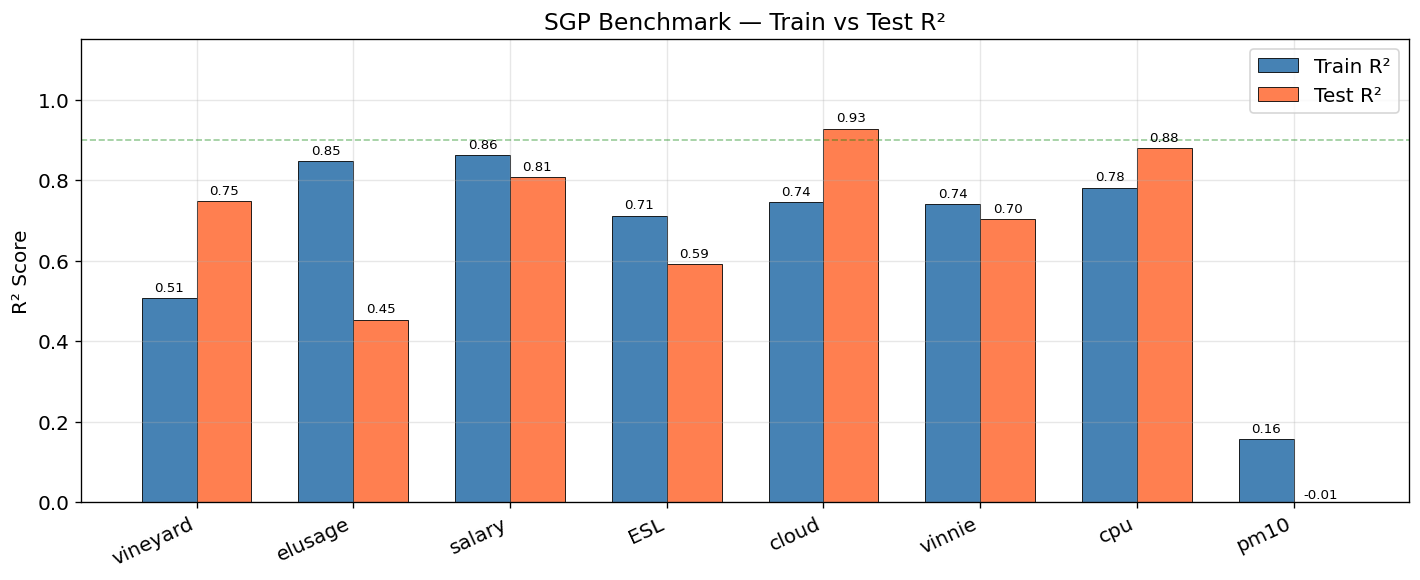

In [5]:
names = [r['dataset'] for r in results]
train_r2s = [r['train_r2'] for r in results]
test_r2s = [r['test_r2'] for r in results]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(names))
width = 0.35

bars_train = ax.bar(x - width/2, train_r2s, width, label='Train R²', color='steelblue', edgecolor='black', linewidth=0.5)
bars_test = ax.bar(x + width/2, test_r2s, width, label='Test R²', color='coral', edgecolor='black', linewidth=0.5)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('R² Score')
ax.set_title('SGP Benchmark — Train vs Test R²')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha='right')
ax.legend()
ax.set_ylim(0, 1.15)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.4, linewidth=1)

fig.tight_layout()
fig.savefig('figures/benchmark_r2_comparison.svg', bbox_inches='tight')
plt.show()

## 可视化: 复杂度 vs 准确率

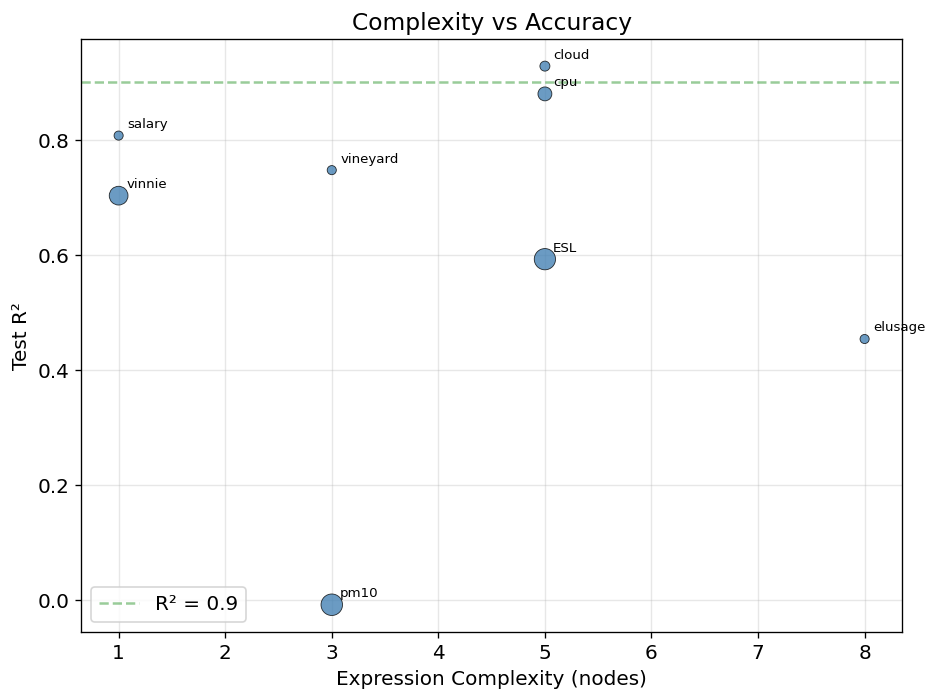

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

complexities = [r['complexity'] for r in results]
sizes = [max(30, r['n_samples'] / 3) for r in results]

ax.scatter(complexities, test_r2s, s=sizes, c='steelblue',
           edgecolors='black', linewidth=0.5, alpha=0.8, zorder=3)

for i, r in enumerate(results):
    ax.annotate(r['dataset'], (r['complexity'], r['test_r2']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Expression Complexity (nodes)')
ax.set_ylabel('Test R²')
ax.set_title('Complexity vs Accuracy')
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.4, label='R² = 0.9')
ax.legend()

fig.tight_layout()
fig.savefig('figures/benchmark_complexity_vs_r2.svg', bbox_inches='tight')
plt.show()

## 可视化: 运行时间分布

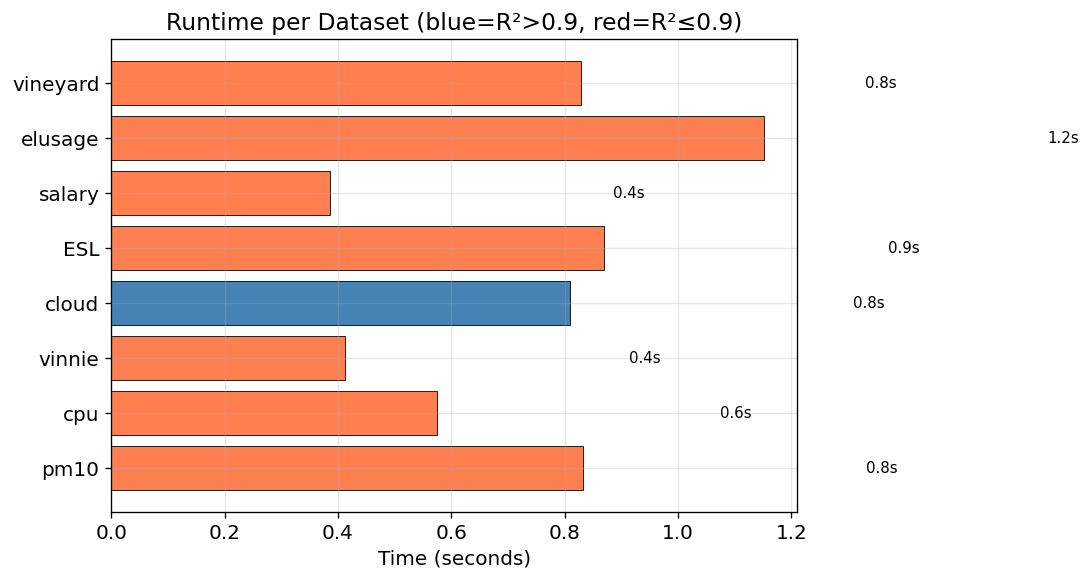

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

times = [r['time'] for r in results]
colors = ['steelblue' if r['test_r2'] > 0.9 else 'coral' for r in results]

bars = ax.barh(names, times, color=colors, edgecolor='black', linewidth=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=9)

ax.set_xlabel('Time (seconds)')
ax.set_title('Runtime per Dataset (blue=R²>0.9, red=R²≤0.9)')
ax.invert_yaxis()

fig.tight_layout()
fig.savefig('figures/pmlb_runtime.svg', bbox_inches='tight')
plt.show()

## 发现的表达式对比

In [8]:
print(f'{"Dataset":<16} {"GP Expression":<45} {"Test R²":>7}')
print('=' * 70)
for r in results:
    expr = r['expression']
    if len(expr) > 42:
        expr = expr[:39] + '...'
    print(f'{r["dataset"]:<16} {expr:<45} {r["test_r2"]:>7.4f}')

Dataset          GP Expression                                 Test R²
vineyard         mul(0.7279327219358993, x0)                    0.7468
elusage          mul(sub(sub(x0, -0.9050302095746343), s...     0.4532
salary           x3                                             0.8069
ESL              mul(sin(sqrt(x3)), x2)                         0.5920
cloud            mul(sqrt(sqrt(x4)), x3)                        0.9277
vinnie           x1                                             0.7025
cpu              mul(x2, sqrt(sqrt(x3)))                        0.8794
pm10             mul(0.381988353050678, x0)                    -0.0089
